# Radial Cone Plotting Pipeline

## Importing Necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval, SqrtStretch
from astropy.coordinates import SkyCoord
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.wcs import WCS
import astropy.units as u
from photutils.centroids import centroid_com
from scipy.ndimage import gaussian_filter, maximum_filter
from scipy.interpolate import interp1d, griddata
import curvelops
import os

## Plotting the Surface Brightness Map

Data shape: (436, 466)


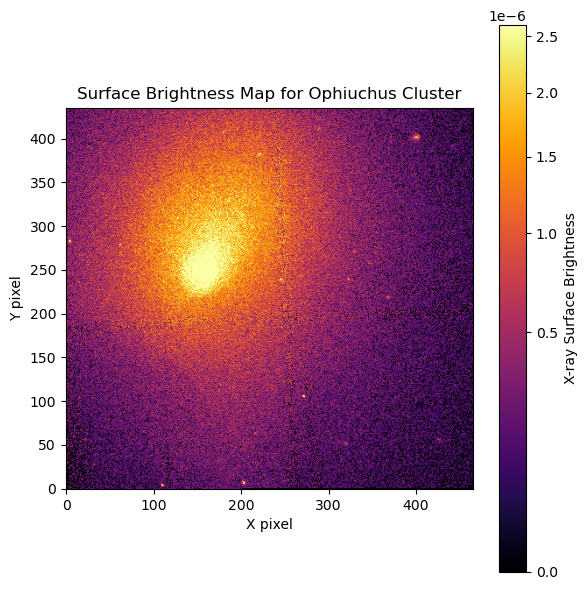

In [2]:
fits_file = "/home/rabbit/Analysis_byClusterPyXT/TEST_16142_16143/main_output/TEST_16142_16143_xray_surface_brightness_cropped.fits"

hdul = fits.open(fits_file)
data = hdul[0].data
header = hdul[0].header
print(f"Data shape: {data.shape}")

data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

norm = ImageNormalize(
    data,
    interval=ZScaleInterval(),
    stretch=SqrtStretch()
)

plt.figure(figsize=(6, 6))
plt.imshow(data, origin='lower', cmap='inferno', norm=norm)
plt.colorbar(label='X-ray Surface Brightness')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.title('Surface Brightness Map for Ophiuchus Cluster')
plt.tight_layout()
plt.show()

## Finding the Centroid of the Map

In [3]:
kernel = Gaussian2DKernel(x_stddev=2)
smooth = convolve(data, kernel, boundary='extend')

center_y_smooth, center_x_smooth = np.unravel_index(
    np.nanargmax(smooth),
    smooth.shape
)

cutout_size = 15
y_min = max(0, center_y_smooth - cutout_size)
y_max = min(data.shape[0], center_y_smooth + cutout_size + 1)
x_min = max(0, center_x_smooth - cutout_size)
x_max = min(data.shape[1], center_x_smooth + cutout_size + 1)

cutout = data[y_min:y_max, x_min:x_max]
cutout = np.clip(cutout, 0, None)

try:
    x_cen, y_cen = centroid_com(cutout)
    center_x_centroid = x_min + x_cen
    center_y_centroid = y_min + y_cen
    print(f"Centroid Position (x, y): ({center_x_centroid:.1f}, {center_y_centroid:.1f})")
except:
    center_x_centroid, center_y_centroid = center_x_smooth, center_y_smooth

Centroid Position (x, y): (156.3, 255.8)


## Radial Cone Mask Construction

Cone boundaries:
Start angle: 45.0°
End angle: 75.0°


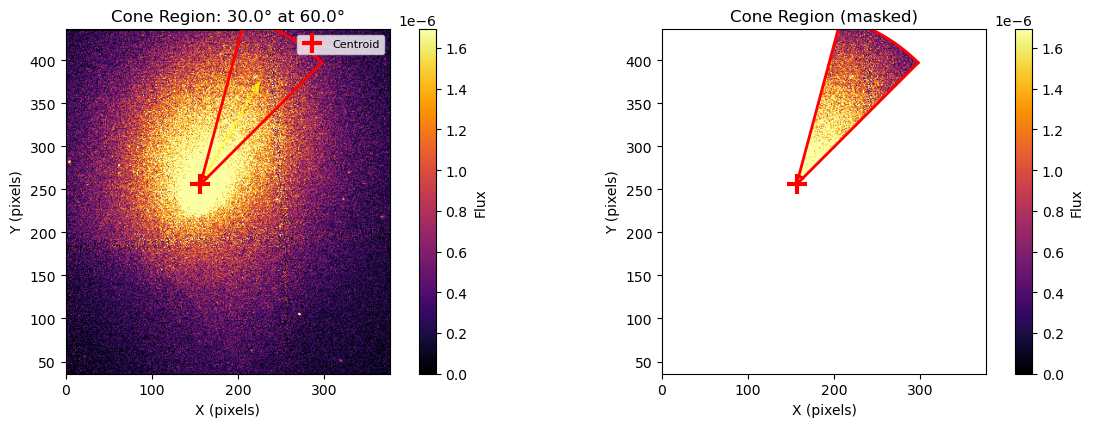

In [4]:
cone_center = (center_x_centroid, center_y_centroid)
cone_angle = 30.0 
cone_direction = 60.0  
inner_radius = 10.0  
outer_radius = 200.0 

cone_angle_rad = np.deg2rad(cone_angle)
cone_direction_rad = np.deg2rad(cone_direction)
angle1 = cone_direction_rad - cone_angle_rad/2
angle2 = cone_direction_rad + cone_angle_rad/2

print(f"Cone boundaries:")
print(f"Start angle: {np.rad2deg(angle1):.1f}°")
print(f"End angle: {np.rad2deg(angle2):.1f}°")

ny, nx = data.shape
y, x = np.indices(data.shape)
dx = x - cone_center[0]
dy = y - cone_center[1]
r = np.sqrt(dx**2 + dy**2)

theta = np.arctan2(dy, dx)  
theta = np.where(theta < 0, theta + 2*np.pi, theta) 
cone_mask = np.zeros_like(data, dtype=bool)
if angle1 < 0:
    cone_mask = ((theta >= (angle1 + 2*np.pi)) | (theta <= angle2)) & \
                (r >= inner_radius) & (r <= outer_radius)
elif angle2 > 2*np.pi:
    cone_mask = ((theta >= angle1) | (theta <= (angle2 - 2*np.pi))) & \
                (r >= inner_radius) & (r <= outer_radius)
else:
    cone_mask = (theta >= angle1) & (theta <= angle2) & \
                (r >= inner_radius) & (r <= outer_radius)

cone_mask = np.zeros_like(data, dtype=bool)

if angle1 < 0:
    cone_mask = ((theta >= (angle1 + 2*np.pi)) | (theta <= angle2)) & \
                (r >= inner_radius) & (r <= outer_radius)
elif angle2 > 2*np.pi:
    cone_mask = ((theta >= angle1) | (theta <= (angle2 - 2*np.pi))) & \
                (r >= inner_radius) & (r <= outer_radius)
else:
    cone_mask = (theta >= angle1) & (theta <= angle2) & \
                (r >= inner_radius) & (r <= outer_radius)

cone_data = data[cone_mask]
cone_radii = r[cone_mask]
cone_angles = theta[cone_mask]

margin = 20 
x_min_plot = max(0, cone_center[0] - outer_radius - margin)
x_max_plot = min(data.shape[1], cone_center[0] + outer_radius + margin)
y_min_plot = max(0, cone_center[1] - outer_radius - margin)
y_max_plot = min(data.shape[0], cone_center[1] + outer_radius + margin)

fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot(3, 3, 1)
vmin, vmax = np.percentile(data, [5, 95])
im1 = ax1.imshow(data, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)

theta_plot = np.linspace(angle1, angle2, 100)
x_inner = cone_center[0] + inner_radius * np.cos(theta_plot)
y_inner = cone_center[1] + inner_radius * np.sin(theta_plot)
x_outer = cone_center[0] + outer_radius * np.cos(theta_plot)
y_outer = cone_center[1] + outer_radius * np.sin(theta_plot)
ax1.plot(x_inner, y_inner, 'r-', linewidth=2)
ax1.plot(x_outer, y_outer, 'r-', linewidth=2)

ax1.plot([cone_center[0], cone_center[0] + outer_radius * np.cos(angle1)],
         [cone_center[1], cone_center[1] + outer_radius * np.sin(angle1)], 'r-', linewidth=2)
ax1.plot([cone_center[0], cone_center[0] + outer_radius * np.cos(angle2)],
         [cone_center[1], cone_center[1] + outer_radius * np.sin(angle2)], 'r-', linewidth=2)

center_x_raw, center_y_raw = np.unravel_index(np.nanargmax(data), data.shape)
ax1.plot(cone_center[0], cone_center[1], 'r+', markersize=15, markeredgewidth=3, label='Centroid')

arrow_length = outer_radius * 0.7
ax1.arrow(cone_center[0], cone_center[1],
          arrow_length * np.cos(cone_direction_rad) * 0.9,
          arrow_length * np.sin(cone_direction_rad) * 0.9,
          head_width=8, head_length=12, fc='yellow', ec='yellow', alpha=0.7)

ax1.set_title(f'Cone Region: {cone_angle}° at {cone_direction}°')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.set_xlim(x_min_plot, x_max_plot)
ax1.set_ylim(y_min_plot, y_max_plot)
ax1.legend(loc='upper right', fontsize=8)
plt.colorbar(im1, ax=ax1, label='Flux')

ax2 = plt.subplot(3, 3, 2)
cone_display = np.full_like(data, np.nan)
cone_display[cone_mask] = data[cone_mask]
im2 = ax2.imshow(cone_display, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
ax2.plot(x_inner, y_inner, 'r-', linewidth=2)
ax2.plot(x_outer, y_outer, 'r-', linewidth=2)
ax2.plot([cone_center[0], cone_center[0] + outer_radius * np.cos(angle1)],
         [cone_center[1], cone_center[1] + outer_radius * np.sin(angle1)], 'r-', linewidth=2)
ax2.plot([cone_center[0], cone_center[0] + outer_radius * np.cos(angle2)],
         [cone_center[1], cone_center[1] + outer_radius * np.sin(angle2)], 'r-', linewidth=2)
ax2.plot(cone_center[0], cone_center[1], 'r+', markersize=15, markeredgewidth=3)

ax2.set_title('Cone Region (masked)')
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
ax2.set_xlim(x_min_plot, x_max_plot)
ax2.set_ylim(y_min_plot, y_max_plot)
plt.colorbar(im2, ax=ax2, label='Flux')

plt.tight_layout()
plt.show()

## Radial Profile Analysis

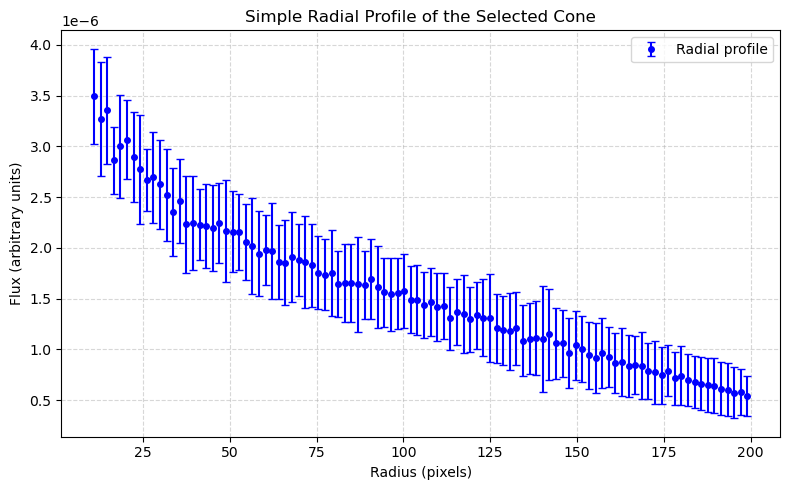

In [5]:
# Method 01: Simple Binning

num_radial_bins = 100
radial_bins = np.linspace(inner_radius, outer_radius, num_radial_bins + 1)
radial_bin_centers = (radial_bins[:-1] + radial_bins[1:]) / 2

radial_profile_simple = []
radial_std_simple = []
radial_counts = []

for i in range(num_radial_bins):
    r_min, r_max = radial_bins[i], radial_bins[i+1]
    radial_mask = (cone_radii >= r_min) & (cone_radii < r_max)
    radial_pixels = cone_data[radial_mask]
    
    if len(radial_pixels) > 0:
        radial_profile_simple.append(np.mean(radial_pixels))
        radial_std_simple.append(np.std(radial_pixels))
        radial_counts.append(len(radial_pixels))
    else:
        radial_profile_simple.append(np.nan)
        radial_std_simple.append(np.nan)
        radial_counts.append(0)

radial_profile_simple = np.array(radial_profile_simple)
radial_std_simple = np.array(radial_std_simple)

plt.figure(figsize=(8, 5))
plt.errorbar(radial_bin_centers, radial_profile_simple, yerr=radial_std_simple,
             fmt='o', markersize=4, capsize=3, color='blue', label='Radial profile')

plt.xlabel('Radius (pixels)')
plt.ylabel('Flux (arbitrary units)')
plt.title('Simple Radial Profile of the Selected Cone')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

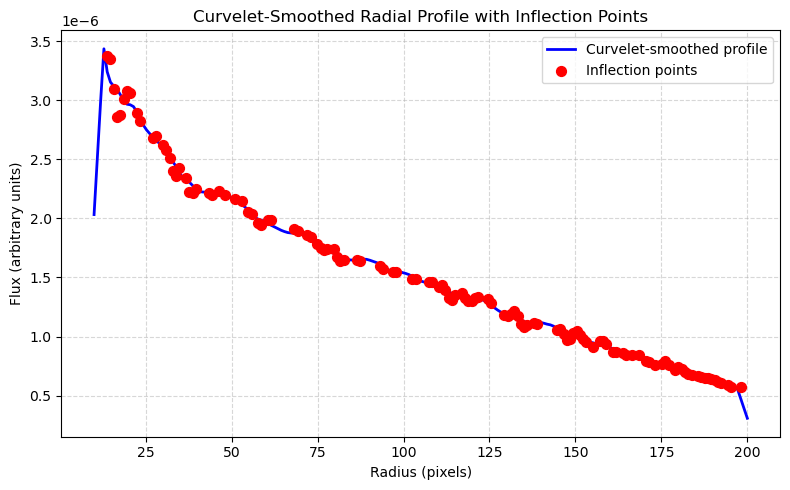

In [6]:
# Method 02: Curvelet Smoothed Radial Profile

valid_indices = ~np.isnan(radial_profile_simple)
r_valid = radial_bin_centers[valid_indices]
f_valid = np.array(radial_profile_simple)[valid_indices]

f_interp = interp1d(r_valid, f_valid, kind='cubic', 
                    bounds_error=False, fill_value='extrapolate')
r_smooth = np.linspace(inner_radius, outer_radius, 200)
f_smooth = f_interp(r_smooth)

num_angular_samples = 100
r_grid, theta_grid = np.meshgrid(
    np.linspace(inner_radius, outer_radius, 100),
    np.linspace(angle1, angle2, num_angular_samples)
)

points = np.column_stack((cone_radii, cone_angles))
values = cone_data
grid_points = np.column_stack((r_grid.ravel(), theta_grid.ravel()))
flux_grid = griddata(points, values, grid_points, method='linear')
flux_2d = flux_grid.reshape(r_grid.shape)
flux_2d = np.nan_to_num(flux_2d, nan=np.nanmean(flux_2d))

def smooth_with_curves(y, window_size=5):
    window = np.ones(window_size) / window_size
    y_smooth = np.convolve(y, window, mode='same')
    return y_smooth

f_smooth_curve = smooth_with_curves(f_smooth, window_size=7)

gradient = np.gradient(f_smooth_curve, r_smooth)
second_deriv = np.gradient(gradient, r_smooth)

inflection_points = []
for i in range(1, len(second_deriv)-1):
    if second_deriv[i-1] * second_deriv[i+1] < 0:
        inflection_points.append(r_smooth[i])

plt.figure(figsize=(8, 5))
plt.plot(r_smooth, f_smooth_curve, color='blue', lw=2, label='Curvelet-smoothed profile')
plt.scatter(inflection_points, f_interp(inflection_points), color='red', s=50, label='Inflection points', zorder=5)

plt.xlabel('Radius (pixels)')
plt.ylabel('Flux (arbitrary units)')
plt.title('Curvelet-Smoothed Radial Profile with Inflection Points')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Radial Profile Comparison

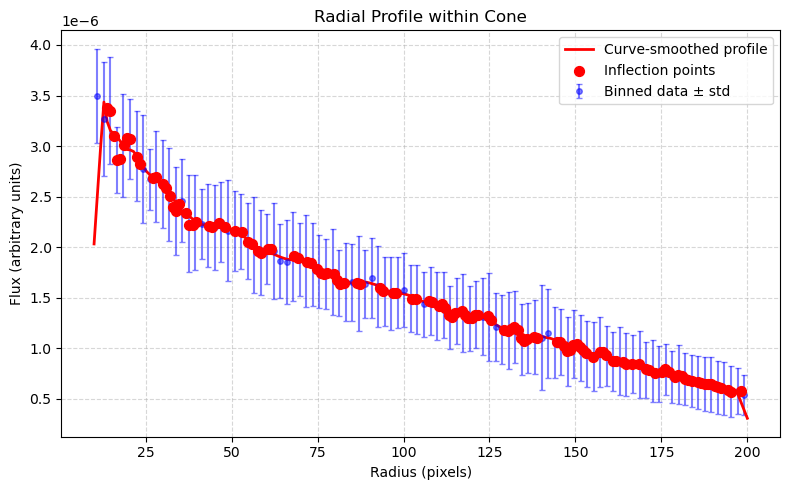

In [7]:
plt.figure(figsize=(8, 5))

plt.errorbar(radial_bin_centers, radial_profile_simple,
             yerr=radial_std_simple, fmt='bo', alpha=0.5,
             capsize=2, label='Binned data ± std', markersize=4)

plt.plot(r_smooth, f_smooth_curve, 'r-', linewidth=2, label='Curve-smoothed profile')
if len(inflection_points) > 0:
    plt.scatter(inflection_points, f_interp(inflection_points), color='red', s=50,
                label='Inflection points', zorder=5)

plt.xlabel('Radius (pixels)')
plt.ylabel('Flux (arbitrary units)')
plt.title('Radial Profile within Cone')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()